# Bilissel Performans Skoru Tahmini

---
## 1. Kutuphaneler & Yapilandirma

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from catboost import CatBoostRegressor; CAT_OK = True; print('CatBoost OK')
except ImportError: CAT_OK = False; print('CatBoost yok')
try:
    import lightgbm as lgb; LGB_OK = True; print('LightGBM OK')
except ImportError: LGB_OK = False; print('LightGBM yok')
try:
    import xgboost as xgb; XGB_OK = True; print('XGBoost OK')
except ImportError: XGB_OK = False; print('XGBoost yok')
try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True; print('Optuna OK')
except ImportError: OPTUNA_OK = False; print('Optuna yok -> pip install optuna')

# Gorsel tema
plt.rcParams.update({'figure.figsize':(14,6), 'axes.spines.top':False,
                     'axes.spines.right':False, 'font.size':11})
sns.set_palette('tab10'); sns.set_style('whitegrid')
SEED = 42; np.random.seed(SEED)
TARGET = 'bilissel_performans_skoru'
print('\nHazir!')

CatBoost OK
LightGBM OK
XGBoost OK
Optuna yok -> pip install optuna

Hazir!


---
## 2. Veri Yukleme & Tip Kontrolu

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test_x.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
train.head(3)

Train : (56000, 24)
Test  : (24000, 23)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276


In [3]:
# Veri tipleri ve eksik deger ozeti
ozet = pd.DataFrame({
    'Dtype':   train.dtypes,
    'Eksik':   train.isnull().sum(),
    'Eksik%':  (train.isnull().sum()/len(train)*100).round(2),
    'Benzersiz': train.nunique(),
    'Ornek':   [train[c].dropna().iloc[0] if train[c].notna().any() else None for c in train.columns]
})
print(ozet.to_string())

                               Dtype  Eksik  Eksik%  Benzersiz                   Ornek
id                             int64      0    0.00      56000                       1
yas                            int64      0    0.00         52                      34
cinsiyet                         str      0    0.00          2                   Erkek
meslek                           str   1378    2.46         11        Saglik Personeli
vucut_kitle_indeksi          float64   1752    3.13      53845               31.470103
ulke                             str      0    0.00         15                     Cin
rem_yuzdesi                  float64      0    0.00      55858                14.43121
derin_uyku_yuzdesi           float64      0    0.00      55596               14.645436
uykuya_dalma_suresi_dk         int64      0    0.00         58                      27
gecelik_uyanma_sayisi          int64      0    0.00          9                       7
uyku_oncesi_kafein_mg        float64   1463

In [4]:
# Sayisal vs Kategorik bolunumu
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', TARGET]]
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'id']

print(f'Sayisal sutunlar ({len(num_cols)}): {num_cols}')
print(f'Kategorik sutunlar ({len(cat_cols)}): {cat_cols}')

Sayisal sutunlar (15): ['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']
Kategorik sutunlar (7): ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']


---
## 3. Hedef Dagilimi & Outlier Analizi

### 3.1 Target Dagilimi (Normal mi, Skew mi?)

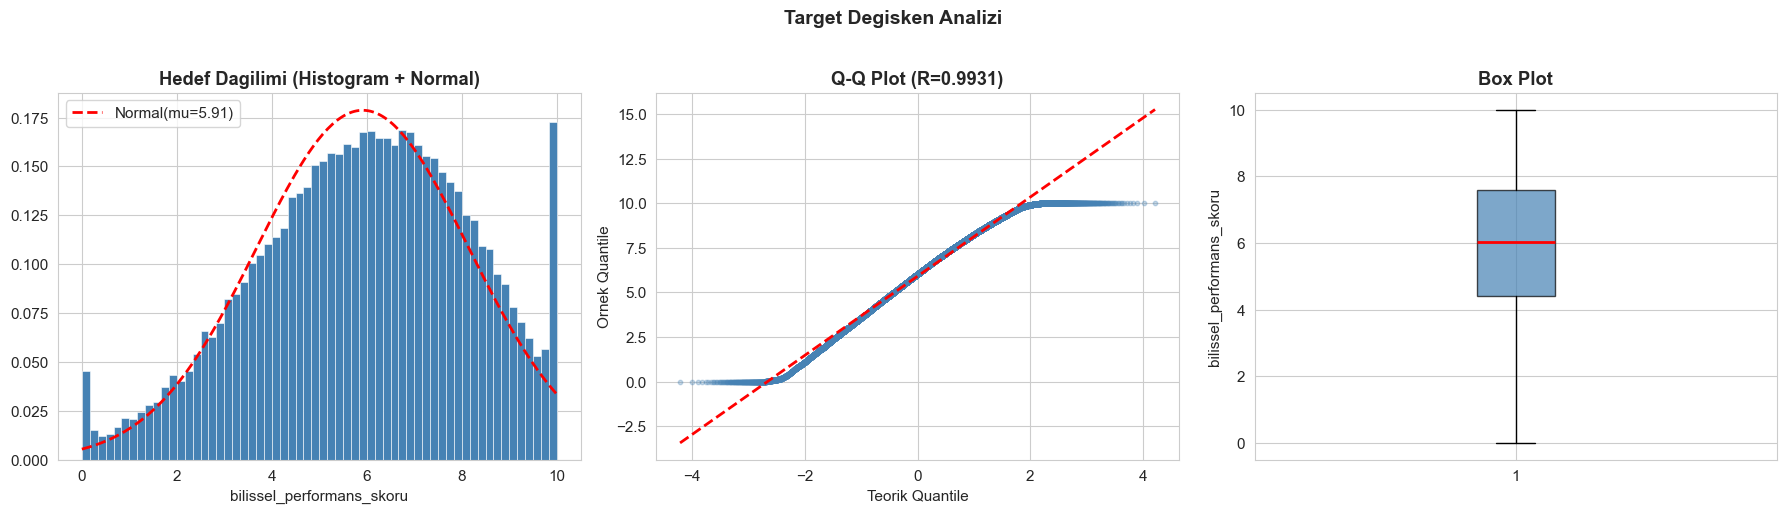

=== Normallik Testleri ===
Carpiklik (Skewness) : -0.2885  (Normal
Basiklik (Kurtosis)  : -0.4340
Shapiro-Wilk         : stat=0.9855, p=0.000000 -> NORMAL DEGIL
KS Testi             : stat=0.0335, p=0.000000 -> NORMAL DEGIL

Log donusumu gerekli: False


In [5]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3)

# Histogram + KDE
ax1 = fig.add_subplot(gs[0])
ax1.hist(train[TARGET], bins=60, color='steelblue', edgecolor='white', lw=0.4, density=True)
xmin, xmax = train[TARGET].min(), train[TARGET].max()
x = np.linspace(xmin, xmax, 200)
mu, std = train[TARGET].mean(), train[TARGET].std()
ax1.plot(x, stats.norm.pdf(x, mu, std), 'r--', lw=2, label=f'Normal(mu={mu:.2f})')
ax1.set_title('Hedef Dagilimi (Histogram + Normal)', fontweight='bold')
ax1.set_xlabel(TARGET); ax1.legend()

# Q-Q Plot
ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r) = stats.probplot(train[TARGET].dropna(), dist='norm')
ax2.scatter(osm, osr, alpha=0.3, s=10, color='steelblue')
ax2.plot(osm, slope*np.array(osm)+intercept, 'r--', lw=2)
ax2.set_title(f'Q-Q Plot (R={r:.4f})', fontweight='bold')
ax2.set_xlabel('Teorik Quantile'); ax2.set_ylabel('Ornek Quantile')

# Box Plot
ax3 = fig.add_subplot(gs[2])
ax3.boxplot(train[TARGET].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='red', lw=2))
ax3.set_title('Box Plot', fontweight='bold')
ax3.set_ylabel(TARGET)

plt.suptitle('Target Degisken Analizi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Istatistiksel testler
stat_sw, p_sw   = stats.shapiro(train[TARGET].dropna().sample(min(5000, len(train)), random_state=SEED))
stat_ks, p_ks   = stats.kstest(train[TARGET].dropna(), 'norm',
                                args=(train[TARGET].mean(), train[TARGET].std()))
skewness        = train[TARGET].skew()
kurtosis        = train[TARGET].kurtosis()

print('=== Normallik Testleri ===')
print(f'Carpiklik (Skewness) : {skewness:.4f}  ('
      f'{"Normal" if abs(skewness)<0.5 else "Hafif Carpik" if abs(skewness)<1 else "Guclu Carpik"}')
print(f'Basiklik (Kurtosis)  : {kurtosis:.4f}')
print(f'Shapiro-Wilk         : stat={stat_sw:.4f}, p={p_sw:.6f} -> '
      f'{"NORMAL" if p_sw>0.05 else "NORMAL DEGIL"}')
print(f'KS Testi             : stat={stat_ks:.4f}, p={p_ks:.6f} -> '
      f'{"NORMAL" if p_ks>0.05 else "NORMAL DEGIL"}')

# Log donusumu gerekli mi?
USE_LOG = abs(skewness) > 0.5
print(f'\nLog donusumu gerekli: {USE_LOG}')

### 3.2 Sayisal Degiskenler - Dagilim & Outlier

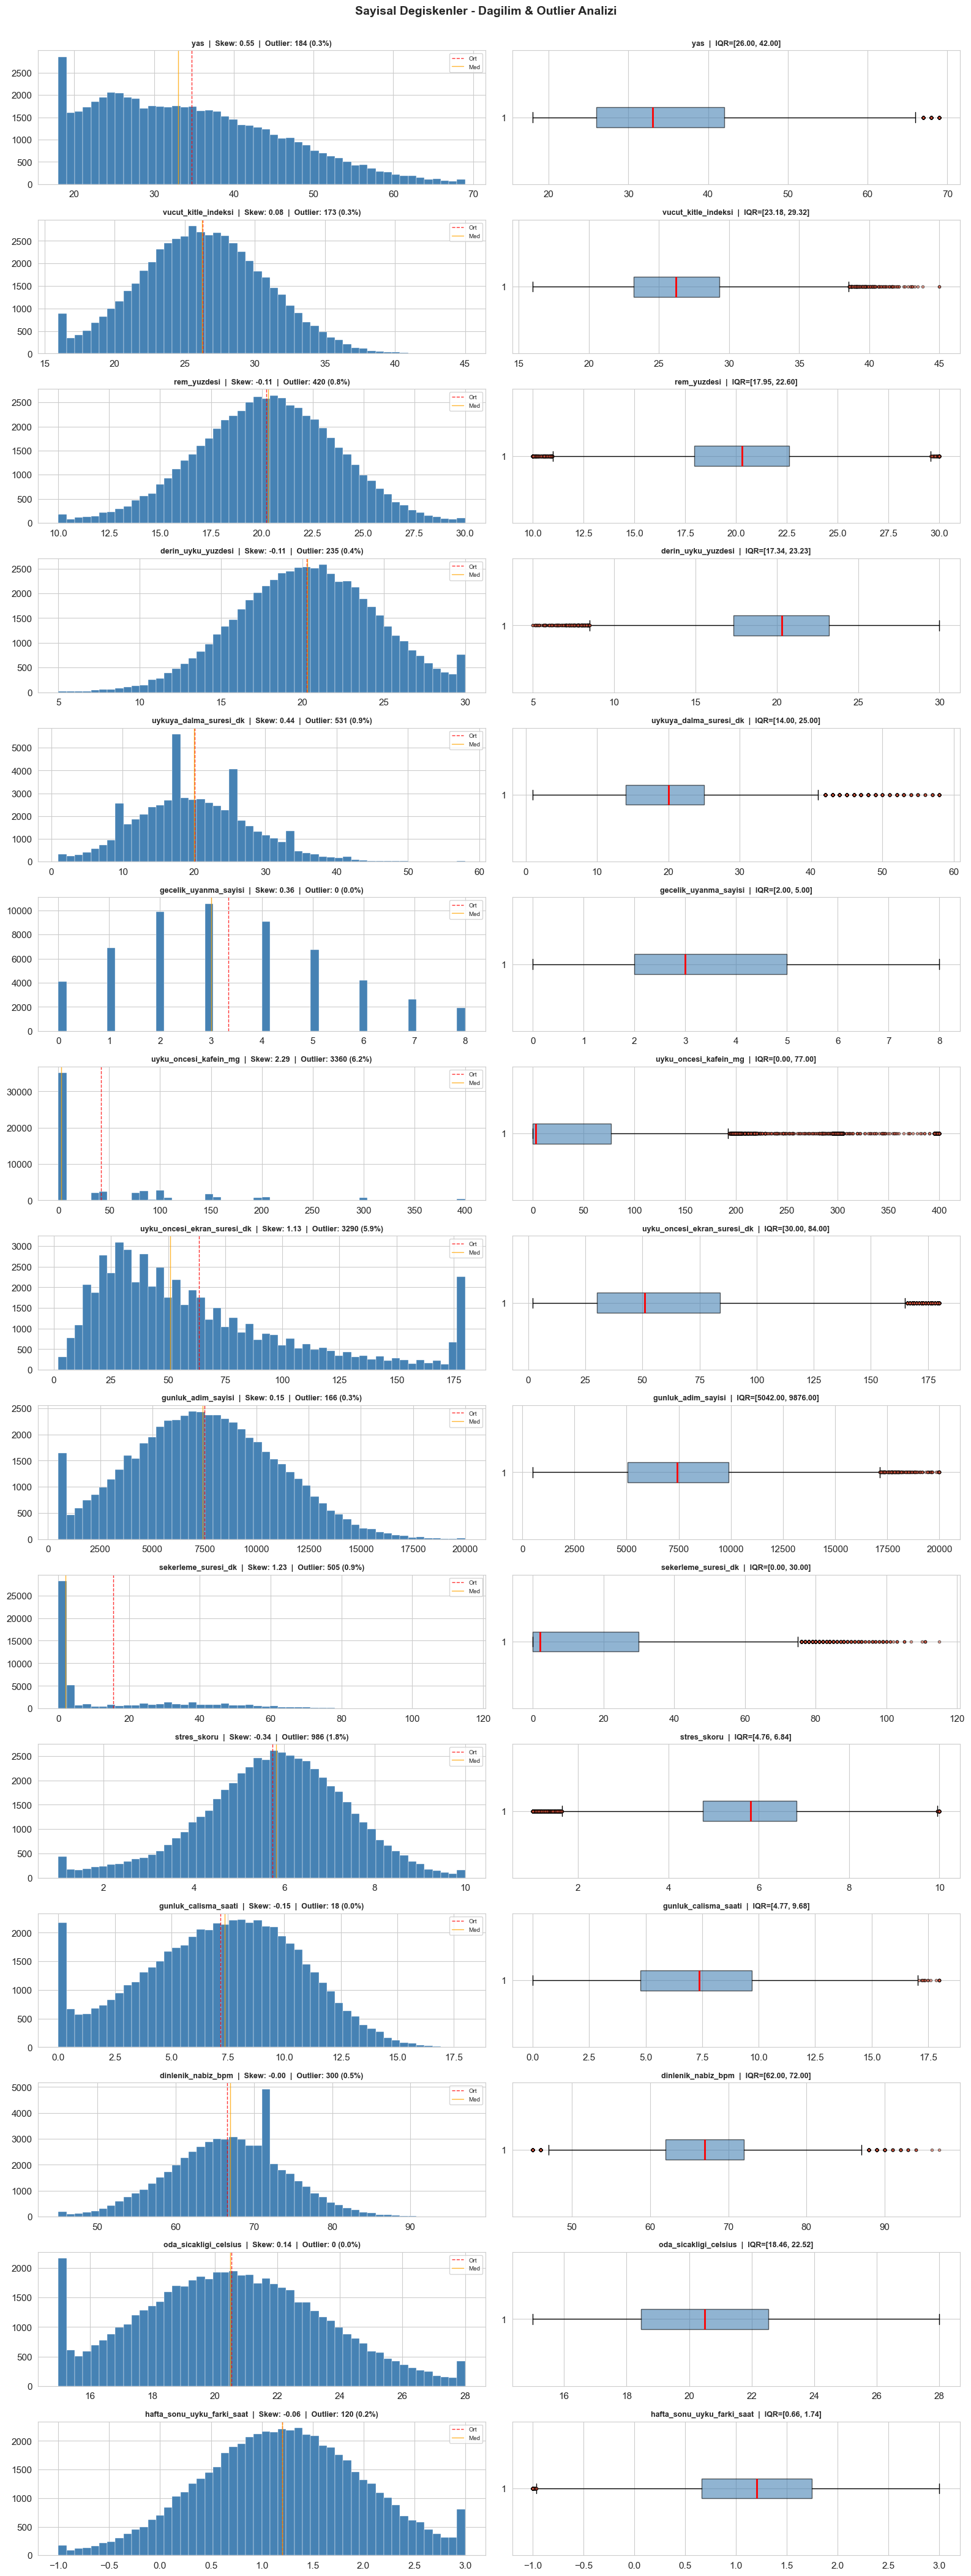

In [ ]:
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(16, n*2.8))

for i, col in enumerate(num_cols):
    s = train[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((s < Q1-1.5*IQR) | (s > Q3+1.5*IQR)).sum()

    # Histogram
    axes[i,0].hist(s, bins=50, color='steelblue', edgecolor='white', lw=0.3)
    axes[i,0].set_title(f'{col}  |  Skew: {s.skew():.2f}  |  Outlier: {n_out} ({n_out/len(s)*100:.1f}%)',
                        fontsize=9, fontweight='bold')
    axes[i,0].axvline(s.mean(),   color='red',    ls='--', lw=1, alpha=0.8, label='Ort')
    axes[i,0].axvline(s.median(), color='orange', ls='-',  lw=1, alpha=0.8, label='Med')
    axes[i,0].legend(fontsize=7)

    # Boxplot
    axes[i,1].boxplot(s, vert=False, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.6),
                      flierprops=dict(marker='o', markerfacecolor='tomato', markersize=3, alpha=0.5),
                      medianprops=dict(color='red', lw=2))
    axes[i,1].set_title(f'{col}  |  IQR=[{Q1:.2f}, {Q3:.2f}]', fontsize=9, fontweight='bold')

plt.suptitle('Sayisal Degiskenler - Dagilim & Outlier Analizi', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout(); plt.show()

                      Sutun  Skewness  Alt Sinir  Ust Sinir  Outlier Sayisi  Outlier %
      uyku_oncesi_kafein_mg     2.295   -115.500    192.500            3360       6.16
uyku_oncesi_ekran_suresi_dk     1.130    -51.000    165.000            3290       5.88
                stres_skoru    -0.341      1.647      9.952             986       1.82
     uykuya_dalma_suresi_dk     0.436     -2.500     41.500             531       0.95
        sekerleme_suresi_dk     1.228    -45.000     75.000             505       0.90
                rem_yuzdesi    -0.114     10.982     29.568             420       0.75
         dinlenik_nabiz_bpm    -0.001     47.000     87.000             300       0.54
         derin_uyku_yuzdesi    -0.112      8.504     32.061             235       0.42
                        yas     0.552      2.000     66.000             184       0.33
        vucut_kitle_indeksi     0.078     13.956     38.541             173       0.32
         gunluk_adim_sayisi     0.151  -220

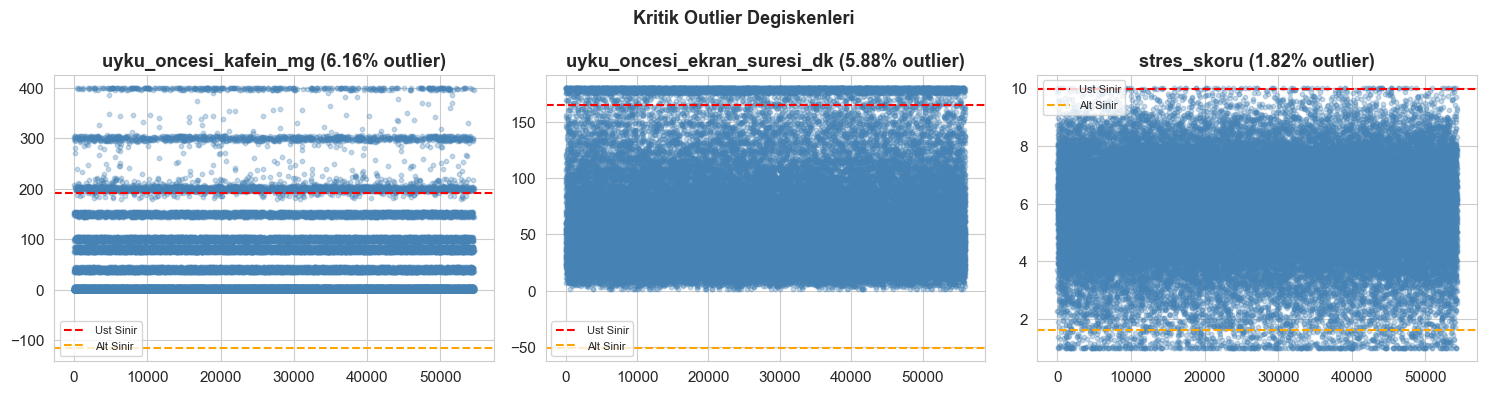

In [ ]:
# Outlier Ozet Tablosu
outlier_rapor = []
for col in num_cols:
    s    = train[col].dropna()
    Q1   = s.quantile(0.25)
    Q3   = s.quantile(0.75)
    IQR  = Q3 - Q1
    alt  = Q1 - 1.5*IQR
    ust  = Q3 + 1.5*IQR
    mask = (s < alt) | (s > ust)
    outlier_rapor.append({
        'Sutun': col, 'Skewness': round(s.skew(),3),
        'Alt Sinir': round(alt,3), 'Ust Sinir': round(ust,3),
        'Outlier Sayisi': mask.sum(),
        'Outlier %': round(mask.sum()/len(s)*100, 2)
    })

out_df = pd.DataFrame(outlier_rapor).sort_values('Outlier %', ascending=False)
print(out_df.to_string(index=False))

kritik = out_df[out_df['Outlier %'] > 1]
if not kritik.empty:
    fig, axes = plt.subplots(1, len(kritik), figsize=(5*len(kritik), 4))
    if len(kritik) == 1: axes = [axes]
    for ax, (_, row) in zip(axes, kritik.iterrows()):
        col = row['Sutun']
        s   = train[col].dropna()
        ax.scatter(range(len(s)), s.values, alpha=0.3, s=10, color='steelblue')
        ax.axhline(row['Ust Sinir'], color='red', ls='--', lw=1.5, label='Ust Sinir')
        ax.axhline(row['Alt Sinir'], color='orange', ls='--', lw=1.5, label='Alt Sinir')
        ax.set_title(f"{col} ({row['Outlier %']}% outlier)", fontweight='bold')
        ax.legend(fontsize=8)
    plt.suptitle('Kritik Outlier Degiskenleri', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 4. Kategorik Degiskenler & Target Iliskisi

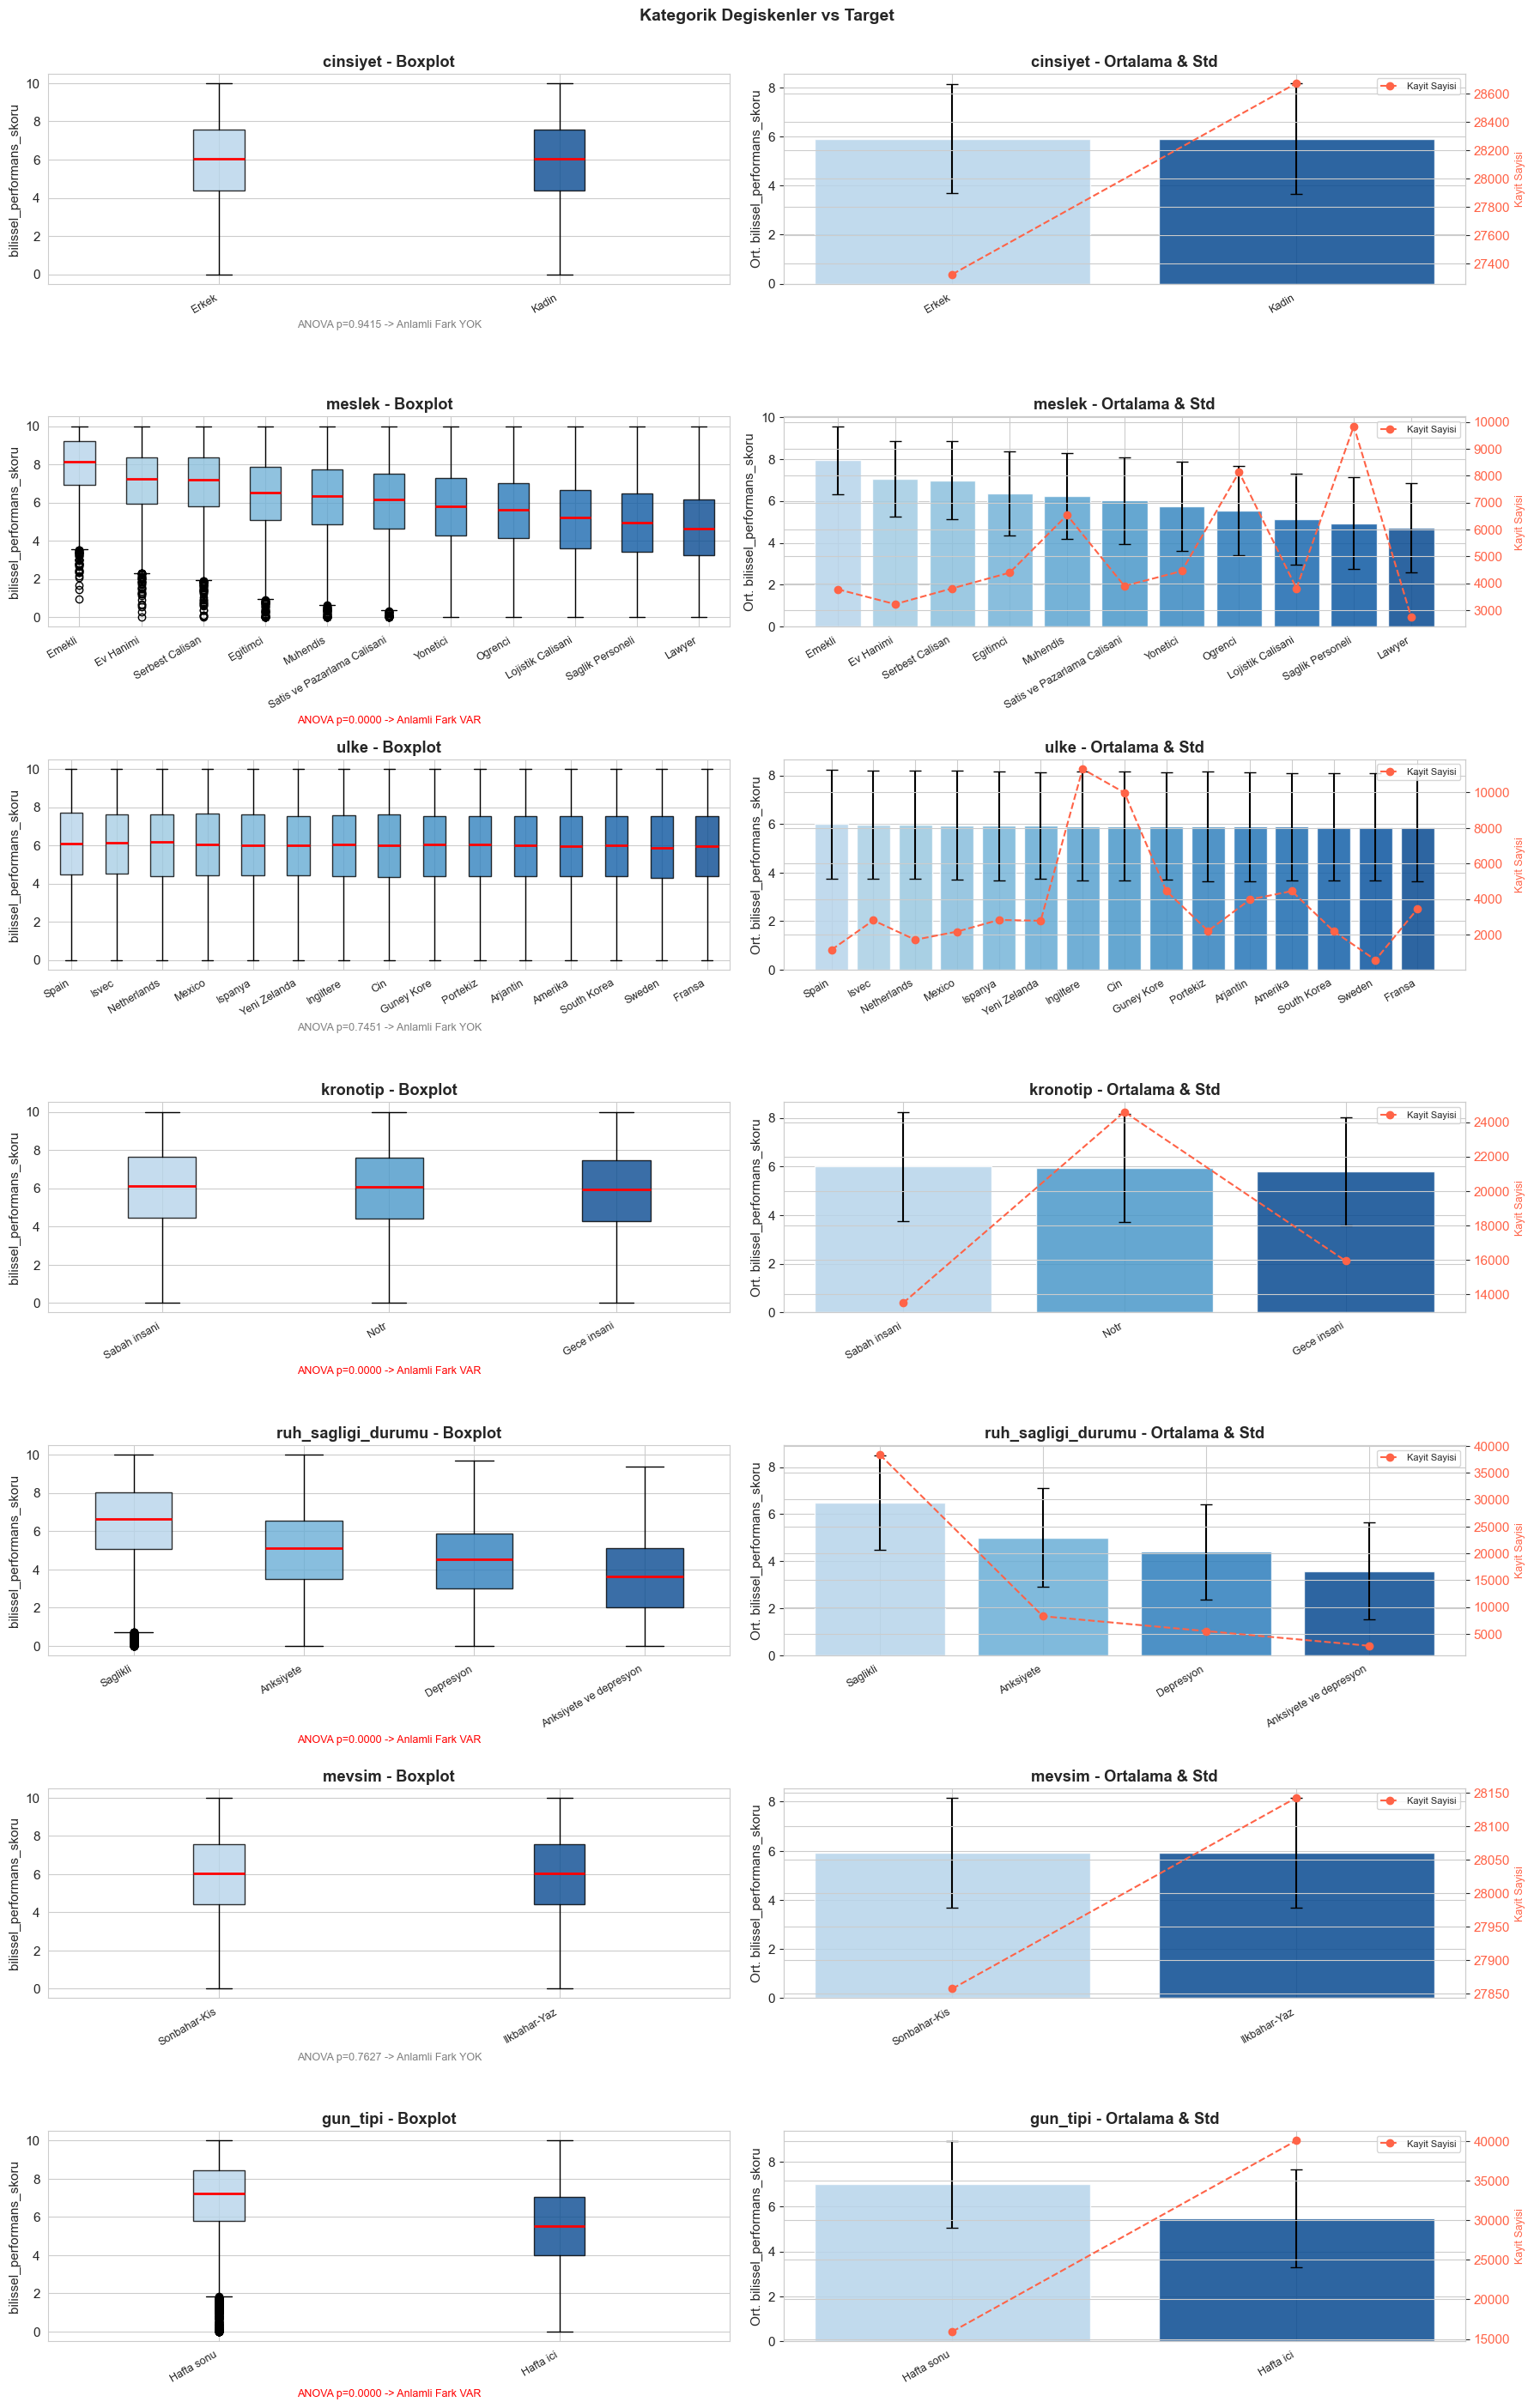

In [ ]:
fig, axes = plt.subplots(len(cat_cols), 2, figsize=(18, len(cat_cols)*4))

for i, col in enumerate(cat_cols):
    grp   = train.groupby(col)[TARGET].agg(['mean','median','std','count'])
    order = grp['mean'].sort_values(ascending=False).index

    # Boxplot
    data_list = [train[train[col]==cat][TARGET].dropna().values for cat in order]
    bp = axes[i,0].boxplot(data_list, labels=order, patch_artist=True,
                            medianprops=dict(color='red', lw=2))
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(order)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    axes[i,0].set_xticklabels(order, rotation=30, ha='right', fontsize=9)
    axes[i,0].set_title(f'{col} - Boxplot', fontweight='bold')
    axes[i,0].set_ylabel(TARGET)

    # Groupby Mean + Std Bar
    means  = grp['mean'].reindex(order)
    stds   = grp['std'].reindex(order)
    counts = grp['count'].reindex(order)
    bars   = axes[i,1].bar(range(len(order)), means, yerr=stds,
                            color=colors, edgecolor='white', capsize=5, alpha=0.85)
    ax2 = axes[i,1].twinx()
    ax2.plot(range(len(order)), counts.values, 'o--', color='tomato',
             markersize=6, lw=1.5, label='Kayit Sayisi')
    ax2.set_ylabel('Kayit Sayisi', color='tomato', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='tomato')
    axes[i,1].set_xticks(range(len(order)))
    axes[i,1].set_xticklabels(order, rotation=30, ha='right', fontsize=9)
    axes[i,1].set_title(f'{col} - Ortalama & Std', fontweight='bold')
    axes[i,1].set_ylabel('Ort. ' + TARGET)
    ax2.legend(loc='upper right', fontsize=8)

    # ANOVA p-degeri
    groups = [train[train[col]==cat][TARGET].dropna().values for cat in train[col].unique()]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) > 1:
        f_stat, p_val = stats.f_oneway(*groups)
        axes[i,0].set_xlabel(f'ANOVA p={p_val:.4f} -> '
                             f'{"Anlamli Fark VAR" if p_val<0.05 else "Anlamli Fark YOK"}',
                             fontsize=9, color='red' if p_val<0.05 else 'gray')

plt.suptitle('Kategorik Degiskenler vs Target', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout(); plt.show()

In [ ]:
print('=== Kategorik Degisken Ozeti (Target Ortalamasi) ===')
for col in cat_cols:
    grp = train.groupby(col)[TARGET].agg(['mean','count']).sort_values('mean', ascending=False)
    print(f'\n--- {col} ---')
    print(grp.to_string())

=== Kategorik Degisken Ozeti (Target Ortalamasi) ===

--- cinsiyet ---
              mean  count
cinsiyet                 
Erkek     5.913804  27324
Kadin     5.912420  28676

--- meslek ---
                                 mean  count
meslek                                      
Emekli                       7.935044   3778
Ev Hanimi                    7.055969   3224
Serbest Calisan              6.985534   3812
Egitimci                     6.343725   4395
Muhendis                     6.223087   6533
Satis ve Pazarlama Calisani  6.010286   3899
Yonetici                     5.729820   4454
Ogrenci                      5.535248   8132
Lojistik Calisani            5.119135   3811
Saglik Personeli             4.930272   9842
Lawyer                       4.719782   2742

--- ulke ---
                  mean  count
ulke                         
Spain         5.990125   1139
Isvec         5.982263   2798
Netherlands   5.974815   1707
Mexico        5.951125   2165
Ispanya       5.924855   2823


---
## 5. Veri Temizleme & Kodlama

### 5.1 Train/Test Birlestirme & id Silme

In [10]:
train_len = len(train)
y         = train[TARGET].copy()

# id'yi sil, hedefi ayir
df = pd.concat([
    train.drop(columns=['id', TARGET]),
    test.drop(columns=['id'])
], axis=0, ignore_index=True)

test_ids = test['id'].copy()

print(f'df boyutu: {df.shape}')
print(f'id silindi, target ayrildi.')

df boyutu: (80000, 22)
id silindi, target ayrildi.


### 5.2 Kategorik Degiskenleri Duzenle

In [11]:
# Kategorik sutunlari standartlastir (bosluk, buyuk/kucuk harf)
cat_cols_df = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols_df:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace('nan', np.nan)

print('Benzersiz degerler (temizlik sonrasi):')
for col in cat_cols_df:
    print(f'  {col:<28}: {sorted(df[col].dropna().unique().tolist())}')

Benzersiz degerler (temizlik sonrasi):
  cinsiyet                    : ['erkek', 'kadin']
  meslek                      : ['egitimci', 'emekli', 'ev hanimi', 'lawyer', 'lojistik calisani', 'muhendis', 'ogrenci', 'saglik personeli', 'satis ve pazarlama calisani', 'serbest calisan', 'yonetici']
  ulke                        : ['amerika', 'arjantin', 'cin', 'fransa', 'guney kore', 'ingiltere', 'ispanya', 'isvec', 'mexico', 'netherlands', 'portekiz', 'south korea', 'spain', 'sweden', 'yeni zelanda']
  kronotip                    : ['gece insani', 'notr', 'sabah insani']
  ruh_sagligi_durumu          : ['anksiyete', 'anksiyete ve depresyon', 'depresyon', 'saglikli']
  mevsim                      : ['ilkbahar-yaz', 'sonbahar-kis']
  gun_tipi                    : ['hafta ici', 'hafta sonu']


In [12]:
# Ordinal kodlama - dogal sira olan degiskenler
# Kronotip: gece insani < ara tip < sabah insani (bilissel etki sirasi)
kronotip_map = {
    'gece insani': 0, 'gece insanı': 0,
    'ara tip': 1, 'intermediate': 1,
    'sabah insani': 2, 'sabah insanı': 2
}
df['kronotip_enc'] = df['kronotip'].map(kronotip_map)
print('kronotip_enc eksik:', df['kronotip_enc'].isnull().sum())

# Ruh sagligi durumu: saglikli > anksiyete > depresyon > anksiyete+depresyon
ruh_map = {
    'saglikli': 3, 'sağlıklı': 3,
    'anksiyete': 2,
    'depresyon': 1,
    'anksiyete ve depresyon': 0
}
df['ruh_sagligi_enc'] = df['ruh_sagligi_durumu'].map(ruh_map)

# Eksik kalan degerleri goster (yazim farki olabilir)
print('ruh_sagligi_enc eksik:', df['ruh_sagligi_enc'].isnull().sum())
if df['ruh_sagligi_enc'].isnull().any():
    print('  Eslesmeyenler:', df[df['ruh_sagligi_enc'].isnull()]['ruh_sagligi_durumu'].value_counts().to_dict())

kronotip_enc eksik: 37936
ruh_sagligi_enc eksik: 1600
  Eslesmeyenler: {}


In [13]:
# Genel kategorik kodlama (Label Encoding + Target Encoding)
label_cols = ['cinsiyet', 'meslek', 'ulke', 'mevsim', 'gun_tipi',
              'kronotip', 'ruh_sagligi_durumu']
label_cols = [c for c in label_cols if c in df.columns]

le = LabelEncoder()

# Target Encoding (train kisminda hesapla, tamamina uygula)
train_part = df.iloc[:train_len].copy()
train_part['__y__'] = y.values
global_mean = y.mean()

for col in label_cols:
    # Label Encoding
    df[col + '_le'] = le.fit_transform(df[col].fillna('eksik').astype(str))

    # Target Encoding
    grp = train_part.groupby(train_part[col].fillna('eksik').astype(str))['__y__'].mean()
    df[col + '_te'] = df[col].fillna('eksik').astype(str).map(grp).fillna(global_mean)

print('Kodlama tamamlandi!')
print([c for c in df.columns if '_le' in c or '_te' in c])

Kodlama tamamlandi!
['cinsiyet_le', 'cinsiyet_te', 'meslek_le', 'meslek_te', 'ulke_le', 'ulke_te', 'mevsim_le', 'mevsim_te', 'gun_tipi_le', 'gun_tipi_te', 'kronotip_le', 'kronotip_te', 'ruh_sagligi_durumu_le', 'ruh_sagligi_durumu_te']


### 5.3 Eksik Veri Doldurma

In [14]:
# Eksik deger durumu
eksik = df.isnull().sum()
eksik = eksik[eksik > 0].sort_values(ascending=False)
if eksik.empty:
    print('Eksik deger yok!')
else:
    print(pd.DataFrame({'Eksik': eksik, '%': (eksik/len(df)*100).round(2)}).to_string())

                       Eksik      %
kronotip_enc           37936  47.42
kronotip                2800   3.50
stres_skoru             2480   3.10
vucut_kitle_indeksi     2400   3.00
uyku_oncesi_kafein_mg   2160   2.70
meslek                  2000   2.50
ruh_sagligi_durumu      1600   2.00
ruh_sagligi_enc         1600   2.00


In [15]:
# Sayisal sutunlar icin KNNImputer (median yerine komsu tabanli)
num_eksik = [c for c in df.select_dtypes(include=[np.number]).columns
             if df[c].isnull().any()]

if num_eksik:
    print(f'KNNImputer uygulaniyor: {num_eksik}')
    imputer = KNNImputer(n_neighbors=5)
    df[num_eksik] = imputer.fit_transform(df[num_eksik])
    print('KNNImputer tamamlandi!')
else:
    print('Sayisal eksik deger yok.')

# Kategorik: mod ile doldur
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f'Kategorik dolduruldu: {col}')

# Ordinal encoding eksikleri de doldur
for col in ['kronotip_enc', 'ruh_sagligi_enc']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print(f'\nToplam NaN: {df.isnull().sum().sum()}')

KNNImputer uygulaniyor: ['vucut_kitle_indeksi', 'uyku_oncesi_kafein_mg', 'stres_skoru', 'kronotip_enc', 'ruh_sagligi_enc']
KNNImputer tamamlandi!
Kategorik dolduruldu: meslek
Kategorik dolduruldu: kronotip
Kategorik dolduruldu: ruh_sagligi_durumu

Toplam NaN: 0


---
## 6. Feature Engineering

In [16]:
# =============================================================
# TABLO'DAN ISTENEN OZELLIKLER + EK GUCLU OZELLIKLER
# =============================================================

# --- Uyku Verimliligi: (derin + rem) / toplam uyku ─────────────────────────
toplam_uyku_proxy = df['derin_uyku_yuzdesi'] + df['rem_yuzdesi']
df['uyku_verimliligi'] = np.where(
    toplam_uyku_proxy > 0,
    toplam_uyku_proxy / 100.0,   # zaten yuzde; normalize et
    np.nan
).astype(float)
df['uyku_verimliligi'] = df['uyku_verimliligi'].fillna(df['uyku_verimliligi'].median())

# --- Uyku Kalitesi Skoru: derin*0.6 + rem*0.4 ──────────────────────────────
df['uyku_kalitesi_skoru'] = df['derin_uyku_yuzdesi']*0.6 + df['rem_yuzdesi']*0.4

# --- Stres-Uyku Etkilesimi ──────────────────────────────────────────────────
df['stres_uyku_etkilesimi'] = df['stres_skoru'] * df['uykuya_dalma_suresi_dk']

# --- Toplam Uyku Suresi Tahmini (derin+rem+hafif proxy) ─────────────────────
# Hafif uyku = 100 - derin - rem (kalan yuzde)
df['hafif_uyku_yuzdesi'] = np.clip(100 - df['derin_uyku_yuzdesi'] - df['rem_yuzdesi'], 0, 100)
df['toplam_uyku_suresi_tahmini'] = df['derin_uyku_yuzdesi'] + df['rem_yuzdesi'] + df['hafif_uyku_yuzdesi']

# --- Kafein x Ekran Etkisi ──────────────────────────────────────────────────
df['kafein_ekran_etkisi'] = df['uyku_oncesi_kafein_mg'] * df['uyku_oncesi_ekran_suresi_dk']

# --- Hafta Ici vs Sonu Farki (mutlak) ───────────────────────────────────────
df['uyku_duzenlilik'] = df['hafta_sonu_uyku_farki_saat'].abs()

# --- BMI x Kronotip ─────────────────────────────────────────────────────────
df['bmi_kronotip'] = df['vucut_kitle_indeksi'] * df['kronotip_enc']

# =============================================================
# EK GUCLU OZELLIKLER
# =============================================================

# --- Fiziksel Saghk Skoru ───────────────────────────────────────────────────
df['fiziksel_saglik'] = df['gunluk_adim_sayisi']/1000 - df['vucut_kitle_indeksi']*0.1

# --- Stres Yuku ─────────────────────────────────────────────────────────────
df['stres_yuku'] = df['stres_skoru'] * df['gunluk_calisma_saati']

# --- Uyku Bozucu Indeksi ────────────────────────────────────────────────────
df['uyku_bozucu'] = (df['uyku_oncesi_kafein_mg']*0.4 +
                     df['uyku_oncesi_ekran_suresi_dk']*0.35 +
                     df['gecelik_uyanma_sayisi']*5 +
                     df['stres_skoru']*0.25)

# --- Oda Sicakligi Sapma (ideal 18-20 C) ────────────────────────────────────
df['sicaklik_sapma'] = (df['oda_sicakligi_celsius'] - 19).abs()

# --- Yas Gruplari (numerik) ─────────────────────────────────────────────────
df['yas_grubu'] = pd.cut(df['yas'], bins=[0,25,35,45,55,200],
                          labels=[0,1,2,3,4]).astype(float)

# --- Adim Etkinligi ─────────────────────────────────────────────────────────
df['adim_etkinligi'] = df['gunluk_adim_sayisi'] / (df['gunluk_calisma_saati'].clip(1, None))

# --- Nabiz-VKI Etkilesimi ───────────────────────────────────────────────────
df['nabiz_bmi'] = df['dinlenik_nabiz_bpm'] * df['vucut_kitle_indeksi']

# --- Sekerleme Var/Yok (binary) ─────────────────────────────────────────────
df['sekerleme_var'] = (df['sekerleme_suresi_dk'] > 0).astype(int)

# --- Kafein Sifir (binary) ──────────────────────────────────────────────────
df['kafein_yok'] = (df['uyku_oncesi_kafein_mg'] == 0).astype(int)

yeni = ['uyku_verimliligi','uyku_kalitesi_skoru','stres_uyku_etkilesimi',
        'hafif_uyku_yuzdesi','toplam_uyku_suresi_tahmini','kafein_ekran_etkisi',
        'uyku_duzenlilik','bmi_kronotip','fiziksel_saglik','stres_yuku',
        'uyku_bozucu','sicaklik_sapma','yas_grubu','adim_etkinligi',
        'nabiz_bmi','sekerleme_var','kafein_yok']

print(f'Uretilen ozellik sayisi: {len(yeni)}')
for f in yeni: print(f'  + {f}')

Uretilen ozellik sayisi: 17
  + uyku_verimliligi
  + uyku_kalitesi_skoru
  + stres_uyku_etkilesimi
  + hafif_uyku_yuzdesi
  + toplam_uyku_suresi_tahmini
  + kafein_ekran_etkisi
  + uyku_duzenlilik
  + bmi_kronotip
  + fiziksel_saglik
  + stres_yuku
  + uyku_bozucu
  + sicaklik_sapma
  + yas_grubu
  + adim_etkinligi
  + nabiz_bmi
  + sekerleme_var
  + kafein_yok


---
## 7. Korelasyon & Ozellik Onemi Analizi

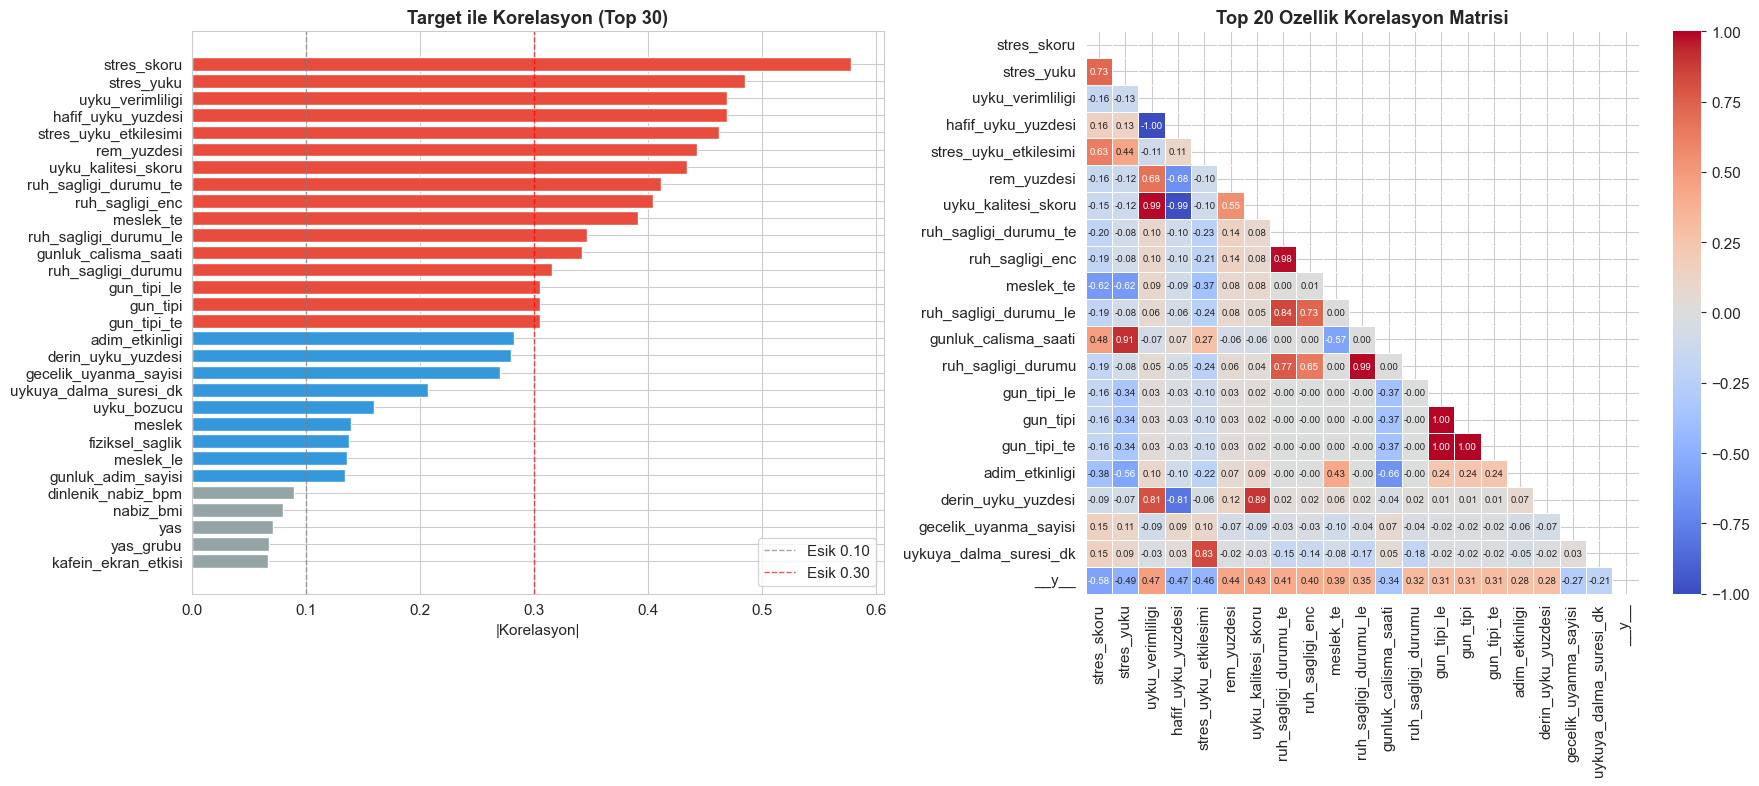

Top 10 ozellik (|korelasyon|):
stres_skoru              0.578095
stres_yuku               0.485551
uyku_verimliligi         0.469163
hafif_uyku_yuzdesi       0.469163
stres_uyku_etkilesimi    0.462336
rem_yuzdesi              0.442999
uyku_kalitesi_skoru      0.434792
ruh_sagligi_durumu_te    0.411264
ruh_sagligi_enc          0.404441
meslek_te                0.391093


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].fillna('eksik').astype(str))

# NaN temizligi
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median() if pd.api.types.is_numeric_dtype(df[col]) else 0)

feature_cols = [c for c in df.columns]  # hepsi numerik simdi
X_all = df.copy()
X_all['__y__'] = y.tolist() + [np.nan]*len(test)

corr_all = X_all.dropna(subset=['__y__'])[feature_cols + ['__y__']].corr()
corr_target = corr_all['__y__'].drop('__y__').abs().sort_values(ascending=False)

# Top 30 korelasyon bar grafigi
top30 = corr_target.head(30)
renkler = ['#e74c3c' if v > 0.3 else '#3498db' if v > 0.1 else '#95a5a6'
           for v in top30.values]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(top30.index[::-1], top30.values[::-1], color=renkler[::-1], edgecolor='white')
axes[0].axvline(0.1, color='gray', ls='--', lw=1, alpha=0.7, label='Esik 0.10')
axes[0].axvline(0.3, color='red',  ls='--', lw=1, alpha=0.7, label='Esik 0.30')
axes[0].set_xlabel('|Korelasyon|'); axes[0].legend()
axes[0].set_title('Target ile Korelasyon (Top 30)', fontweight='bold')

# Isı haritasi (top 20)
top20_cols = corr_target.head(20).index.tolist() + ['__y__']
corr_sub   = corr_all.loc[top20_cols, top20_cols]
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size':7}, ax=axes[1])
axes[1].set_title('Top 20 Ozellik Korelasyon Matrisi', fontweight='bold')

plt.tight_layout(); plt.show()

print(f'Top 10 ozellik (|korelasyon|):')
print(corr_target.head(10).to_string())

---
## 8. Model Karsilastirmasi (Baseline CV)

In [18]:
# Winsorization (outlier kırpma)
feature_cols = [c for c in df.columns]
for col in feature_cols:
    p1, p99 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col]  = df[col].clip(p1, p99)

# Train/Test matrisler
X_train = np.nan_to_num(df.iloc[:train_len].values.astype(np.float64))
X_test  = np.nan_to_num(df.iloc[train_len:].values.astype(np.float64))

assert not np.isnan(X_train).any()
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

# Hedef donusum
USE_LOG = abs(y.skew()) > 0.5
shift   = 0
if USE_LOG:
    shift   = max(0.0, -y.min() + 1e-6)
    y_model = np.log1p(y + shift)
    print(f'Log1p donusumu: carpiklik {y.skew():.3f} -> {y_model.skew():.3f}')
else:
    y_model = y.copy()
    print(f'Donusum gerekmedi (carpiklik={y.skew():.3f})')

def rmse(yt, yp): return np.sqrt(mean_squared_error(yt, yp))
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

X_train: (56000, 55) | X_test: (24000, 55)
Donusum gerekmedi (carpiklik=-0.289)


Model                | RMSE Ort   | RMSE Std
----------------------------------------------
RandomForest         | 1.2704     | 0.0096
CatBoost             | 1.2208     | 0.0099
LightGBM             | 1.2325     | 0.0107
XGBoost              | 1.2318     | 0.0092

En iyi model: CatBoost (RMSE=1.2208)


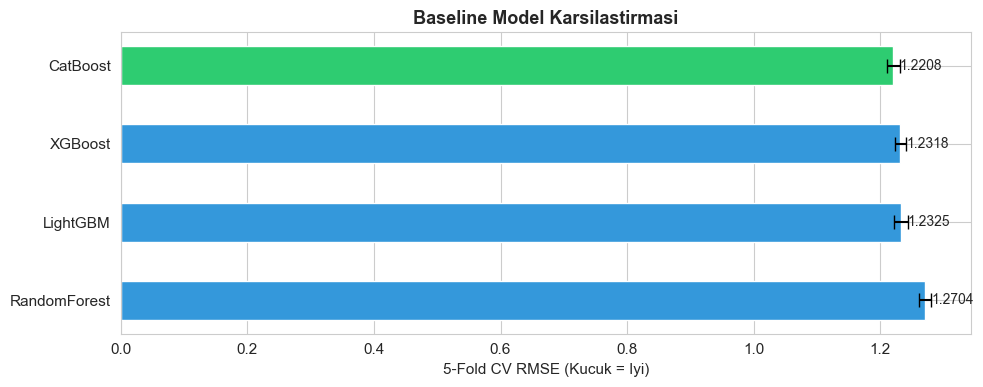

In [19]:
# Tum modeller icin 5-Fold CV
modeller = {'RandomForest': RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED)}
if CAT_OK: modeller['CatBoost']  = CatBoostRegressor(iterations=300, learning_rate=0.05,
                                                       depth=6, random_seed=SEED, verbose=0)
if LGB_OK: modeller['LightGBM']  = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                                       num_leaves=63, random_state=SEED, verbosity=-1, n_jobs=-1)
if XGB_OK: modeller['XGBoost']   = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                                                      max_depth=6, random_state=SEED, verbosity=0, n_jobs=-1)

sonuclar = {}
print(f'{'Model':<20} | RMSE Ort   | RMSE Std')
print('-'*46)
for ad, model in modeller.items():
    try:
        sc = -cross_val_score(model, X_train, y_model, cv=kf,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
        sonuclar[ad] = sc
        print(f'{ad:<20} | {sc.mean():.4f}     | {sc.std():.4f}')
    except Exception as e:
        print(f'{ad:<20} | HATA: {e}')

en_iyi = min(sonuclar, key=lambda k: sonuclar[k].mean())
print(f'\nEn iyi model: {en_iyi} (RMSE={sonuclar[en_iyi].mean():.4f})')

# Grafik
fig, ax = plt.subplots(figsize=(10, 4))
s_df = pd.DataFrame({'Model': list(sonuclar), 'RMSE': [v.mean() for v in sonuclar.values()],
                     'Std':   [v.std()  for v in sonuclar.values()]}).sort_values('RMSE')
renkler = ['#2ecc71' if i==0 else '#3498db' for i in range(len(s_df))]
ax.barh(s_df['Model'][::-1], s_df['RMSE'][::-1], xerr=s_df['Std'][::-1],
        color=renkler[::-1], edgecolor='white', capsize=5, height=0.5)
for i,(r,s) in enumerate(zip(s_df['RMSE'][::-1],s_df['Std'][::-1])):
    ax.text(r+s+0.0002, i, f'{r:.4f}', va='center', fontsize=10)
ax.set_xlabel('5-Fold CV RMSE (Kucuk = Iyi)')
ax.set_title('Baseline Model Karsilastirmasi', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 9. CatBoost Hiperparametre Optimizasyonu

In [20]:
if not CAT_OK:
    raise RuntimeError('CatBoost yuklu degil! pip install catboost')

# Baz RMSE
cat_baz = CatBoostRegressor(iterations=500, random_seed=SEED, verbose=0)
baz_sc  = -cross_val_score(cat_baz, X_train, y_model, cv=kf,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
BAZ_RMSE = baz_sc.mean()
print(f'Baz CatBoost RMSE (varsayilan): {BAZ_RMSE:.4f} +/- {baz_sc.std():.4f}')

Baz CatBoost RMSE (varsayilan): 1.2297 +/- 0.0087


In [21]:
# ── ASAMA 1: RandomizedSearchCV (100 iterasyon) ──────────────────────────────
print('ASAMA 1: RandomizedSearchCV basliyor (100 iterasyon)...')

cat_param_genis = {
    'iterations':         [300, 500, 700, 1000, 1500, 2000],
    'learning_rate':      [0.003, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    'depth':              [4, 5, 6, 7, 8, 9, 10],
    'l2_leaf_reg':        [1, 2, 3, 5, 7, 10, 15, 20],
    'bagging_temperature':[0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0],
    'random_strength':    [0.0, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0],
    'border_count':       [32, 64, 128, 255],
    'min_data_in_leaf':   [1, 3, 5, 10, 15, 20],
    'subsample':          [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel':  [0.6, 0.7, 0.8, 0.9, 1.0],
}

cat_rs = RandomizedSearchCV(
    CatBoostRegressor(random_seed=SEED, verbose=0, task_type='CPU'),
    cat_param_genis, n_iter=100, cv=kf,
    scoring='neg_root_mean_squared_error',
    random_state=SEED, verbose=1, n_jobs=-1
)
cat_rs.fit(X_train, y_model)

RMSE_A1 = -cat_rs.best_score_
print(f'\nAsama 1 RMSE : {RMSE_A1:.4f}  (baza gore iyilesme: {BAZ_RMSE-RMSE_A1:+.4f})')
print('En iyi parametreler:')
for k,v in sorted(cat_rs.best_params_.items()): print(f'  {k:<24}: {v}')

ASAMA 1: RandomizedSearchCV basliyor (100 iterasyon)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Asama 1 RMSE : 1.2200  (baza gore iyilesme: +0.0097)
En iyi parametreler:
  bagging_temperature     : 0.7
  border_count            : 64
  colsample_bylevel       : 0.8
  depth                   : 4
  iterations              : 2000
  l2_leaf_reg             : 5
  learning_rate           : 0.02
  min_data_in_leaf        : 15
  random_strength         : 0.3
  subsample               : 0.8


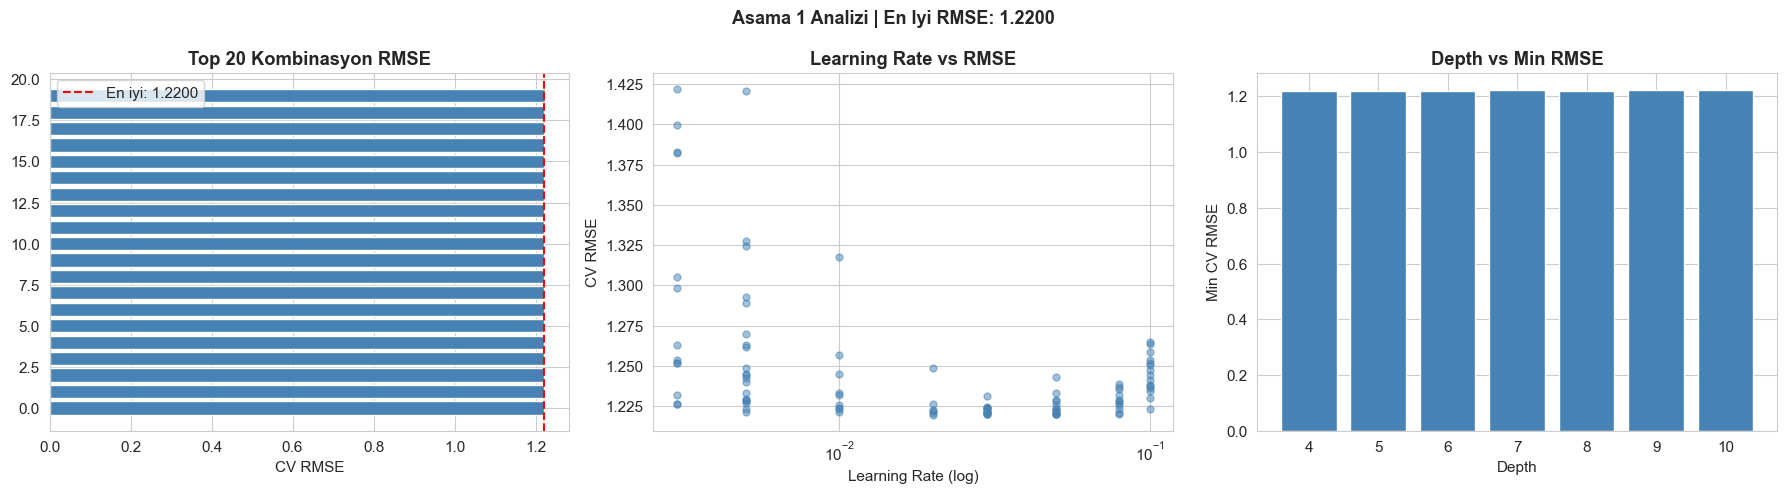

In [22]:
# Asama 1 Gorsel Analizi
rs_df = pd.DataFrame(cat_rs.cv_results_)
rs_df['rmse'] = -rs_df['mean_test_score']
rs_df = rs_df.sort_values('rmse')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(range(20), rs_df['rmse'].values[:20], color='steelblue', edgecolor='white')
axes[0].axvline(RMSE_A1, color='red', ls='--', lw=1.5, label=f'En iyi: {RMSE_A1:.4f}')
axes[0].set_title('Top 20 Kombinasyon RMSE', fontweight='bold')
axes[0].set_xlabel('CV RMSE'); axes[0].legend()

if 'param_learning_rate' in rs_df.columns:
    axes[1].scatter(rs_df['param_learning_rate'].astype(float), rs_df['rmse'],
                    alpha=0.5, s=25, color='steelblue')
    axes[1].set_xscale('log'); axes[1].set_xlabel('Learning Rate (log)')
    axes[1].set_ylabel('CV RMSE'); axes[1].set_title('Learning Rate vs RMSE', fontweight='bold')

if 'param_depth' in rs_df.columns:
    depth_grp = rs_df.groupby('param_depth')['rmse'].min()
    axes[2].bar(depth_grp.index.astype(str), depth_grp.values, color='steelblue', edgecolor='white')
    axes[2].set_xlabel('Depth'); axes[2].set_ylabel('Min CV RMSE')
    axes[2].set_title('Depth vs Min RMSE', fontweight='bold')

plt.suptitle(f'Asama 1 Analizi | En Iyi RMSE: {RMSE_A1:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── ASAMA 2: GridSearchCV (Dar Ince Ayar) ────────────────────────────────────
print('ASAMA 2: GridSearchCV ince ayar basliyor...')

bp = cat_rs.best_params_

def komsu(val, oran=0.2, n=3, tip='int', minv=0):
    if tip == 'float':
        return sorted(set([max(minv, round(val*(1+d*oran),5)) for d in range(-(n//2),n//2+1)]))
    delta = max(1, int(val*oran))
    return sorted(set([max(minv, val+d*delta) for d in range(-(n//2),n//2+1)]))

cat_param_dar = {
    'iterations':         komsu(bp['iterations'],       0.2, 5, 'int',   100),
    'learning_rate':      komsu(bp['learning_rate'],    0.2, 3, 'float', 0.001),
    'depth':              sorted({max(3,bp['depth']-1), bp['depth'], min(10,bp['depth']+1)}),
    'l2_leaf_reg':        komsu(bp['l2_leaf_reg'],      0.3, 3, 'float', 0.5),
    'bagging_temperature':[round(max(0,bp['bagging_temperature']-0.1),3),
                           round(bp['bagging_temperature'],3),
                           round(min(1,bp['bagging_temperature']+0.1),3)],
    'random_strength':    [round(max(0,bp['random_strength']-0.2),3),
                           round(bp['random_strength'],3),
                           round(min(3,bp['random_strength']+0.2),3)],
    'subsample':          [round(max(0.5,bp.get('subsample',0.8)-0.1),2),
                           round(bp.get('subsample',0.8),2),
                           round(min(1.0,bp.get('subsample',0.8)+0.1),2)],
    'border_count':       [bp['border_count']],
    'min_data_in_leaf':   sorted({max(1,bp['min_data_in_leaf']-2),
                                   bp['min_data_in_leaf'],
                                   bp['min_data_in_leaf']+2}),
}

toplam = 1
print('Grid araligi:')
for k,v in cat_param_dar.items():
    print(f'  {k:<24}: {v}'); toplam *= len(v)
print(f'Toplam kombinasyon: {toplam}')

cat_grd = GridSearchCV(
    CatBoostRegressor(random_seed=SEED, verbose=0, task_type='CPU'),
    cat_param_dar, cv=kf,
    scoring='neg_root_mean_squared_error',
    verbose=1, n_jobs=-1
)
cat_grd.fit(X_train, y_model)

RMSE_A2 = -cat_grd.best_score_
print(f'\nAsama 2 RMSE : {RMSE_A2:.4f}  (Asama1 -> 2 kazanim: {RMSE_A1-RMSE_A2:+.4f})')
print('En iyi parametreler:')
for k,v in sorted(cat_grd.best_params_.items()): print(f'  {k:<24}: {v}')

ASAMA 2: GridSearchCV ince ayar basliyor...
Grid araligi:
  iterations              : [1200, 1600, 2000, 2400, 2800]
  learning_rate           : [0.016, 0.02, 0.024]
  depth                   : [3, 4, 5]
  l2_leaf_reg             : [3.5, 5.0, 6.5]
  bagging_temperature     : [0.6, 0.7, 0.8]
  random_strength         : [0.1, 0.3, 0.5]
  subsample               : [0.7, 0.8, 0.9]
  border_count            : [64]
  min_data_in_leaf        : [13, 15, 17]
Toplam kombinasyon: 10935
Fitting 5 folds for each of 10935 candidates, totalling 54675 fits


In [ ]:
# ── ASAMA 3: Optuna TPE Bayesian Optimization (150 trial) ─────────────────────
if OPTUNA_OK:
    print('ASAMA 3: Optuna TPE Bayesian Optimization basliyor (150 trial)...')

    def objective(trial):
        params = {
            'iterations':         trial.suggest_int('iterations', 200, 3000),
            'learning_rate':      trial.suggest_float('learning_rate', 0.003, 0.15, log=True),
            'depth':              trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 0.5, 25.0, log=True),
            'bagging_temperature':trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength':    trial.suggest_float('random_strength', 0.0, 3.0),
            'border_count':       trial.suggest_categorical('border_count', [32,64,128,255]),
            'min_data_in_leaf':   trial.suggest_int('min_data_in_leaf', 1, 30),
            'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'random_seed': SEED, 'verbose': 0, 'task_type': 'CPU',
        }
        sc = cross_val_score(CatBoostRegressor(**params), X_train, y_model,
                             cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
        return -sc.mean()

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=20)
    )
    study.enqueue_trial(cat_grd.best_params_)  # Asama 2 bilgisini ver
    study.optimize(objective, n_trials=150, show_progress_bar=True)

    RMSE_A3 = study.best_value
    print(f'\nAsama 3 RMSE : {RMSE_A3:.4f}  (Asama2 -> 3 kazanim: {RMSE_A2-RMSE_A3:+.4f})')
    print('En iyi parametreler:')
    for k,v in sorted(study.best_params.items()): print(f'  {k:<24}: {v}')
else:
    RMSE_A3 = float('inf')
    print('Optuna yuklu degil. pip install optuna ile yukleyebilirsiniz.')

In [ ]:
if OPTUNA_OK:
    trials_df = study.trials_dataframe()
    done = trials_df[trials_df['state']=='COMPLETE']
    seyir = [min(done['value'].values[:i+1]) for i in range(len(done))]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Optimizasyon seyri
    axes[0,0].scatter(range(len(done)), done['value'].values,
                      alpha=0.35, s=20, color='steelblue', label='Her trial')
    axes[0,0].plot(range(len(seyir)), seyir, 'r-', lw=2, label='En iyi (kumulatif)')
    axes[0,0].set_xlabel('Trial'); axes[0,0].set_ylabel('CV RMSE')
    axes[0,0].set_title('Optuna Optimizasyon Seyri', fontweight='bold'); axes[0,0].legend()

    # Parametre onemi
    imp = optuna.importance.get_param_importances(study)
    axes[0,1].barh(list(imp.keys())[::-1], list(imp.values())[::-1],
                   color='steelblue', edgecolor='white')
    axes[0,1].set_xlabel('Onem Skoru')
    axes[0,1].set_title('Parametre Onemi (Optuna)', fontweight='bold')

    # Learning rate dagilimi
    if 'params_learning_rate' in done.columns:
        top10p = done.nsmallest(max(1,len(done)//10), 'value')
        axes[1,0].hist(done['params_learning_rate'], bins=25, color='lightblue', edgecolor='white', label='Tum')
        axes[1,0].hist(top10p['params_learning_rate'], bins=15, color='steelblue', edgecolor='white', alpha=0.9, label='Top 10%')
        axes[1,0].set_xlabel('Learning Rate'); axes[1,0].set_xscale('log')
        axes[1,0].set_title('Learning Rate Dagilimi', fontweight='bold'); axes[1,0].legend()

    # Depth dagilimi
    if 'params_depth' in done.columns:
        d_grp = done.groupby('params_depth')['value'].min()
        axes[1,1].bar(d_grp.index.astype(str), d_grp.values, color='steelblue', edgecolor='white')
        axes[1,1].set_xlabel('Depth'); axes[1,1].set_ylabel('Min CV RMSE')
        axes[1,1].set_title('Depth vs Min RMSE', fontweight='bold')

    plt.suptitle(f'Optuna Analizi | En Iyi RMSE: {RMSE_A3:.4f}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 9b. Final CatBoost Secimi & Submission

In [ ]:
# Asama karsilastirmasi
karsilastirma = {'Baz': BAZ_RMSE, 'Asama1 Random': RMSE_A1, 'Asama2 Grid': RMSE_A2}
if OPTUNA_OK: karsilastirma['Asama3 Optuna'] = RMSE_A3

print('=== ASAMA KARSILASTIRMASI ===')
for k,v in karsilastirma.items():
    flag = '  <<< EN IYI' if v == min(karsilastirma.values()) else ''
    print(f'  {k:<22}: {v:.4f}  (kazanim: {BAZ_RMSE-v:+.4f}){flag}')

fig, ax = plt.subplots(figsize=(10, 4))
renkler = ['#2ecc71' if v==min(karsilastirma.values()) else '#3498db'
           for v in karsilastirma.values()]
bars = ax.bar(list(karsilastirma.keys()), list(karsilastirma.values()),
              color=renkler, edgecolor='white', width=0.5)
for bar,v in zip(bars, karsilastirma.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
            f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('5-Fold CV RMSE')
ax.set_ylim(min(karsilastirma.values())*0.97, BAZ_RMSE*1.02)
ax.set_title('Optimizasyon Asama Karsilastirmasi', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
if OPTUNA_OK and RMSE_A3 <= min(RMSE_A1, RMSE_A2):
    best_p = dict(study.best_params)
    print('Optuna parametreleri secildi.')
elif RMSE_A2 <= RMSE_A1:
    best_p = dict(cat_grd.best_params_)
    print('GridSearch parametreleri secildi.')
else:
    best_p = dict(cat_rs.best_params_)
    print('RandomizedSearch parametreleri secildi.')

best_p.update({'random_seed': SEED, 'verbose': 0, 'task_type': 'CPU'})

final_cat = CatBoostRegressor(**best_p)
final_cat.fit(X_train, y_model)

pr = final_cat.predict(X_train)
train_pred = np.expm1(pr) - shift if USE_LOG else pr
cat_rmse = rmse(y, train_pred)
cat_r2   = r2_score(y, train_pred)
cat_mae  = mean_absolute_error(y, train_pred)

print(f'\nFinal CatBoost Train RMSE: {cat_rmse:.4f}')
print(f'Final CatBoost Train R2  : {cat_r2:.4f}')
print(f'Final CatBoost Train MAE : {cat_mae:.4f}')

In [ ]:
# Feature Importance
imp = pd.DataFrame({'Ozellik': feature_cols,
                    'Onem': final_cat.get_feature_importance()}
                  ).sort_values('Onem', ascending=False).head(25)

renkler = ['#e74c3c' if i<5 else '#3498db' if i<12 else '#95a5a6' for i in range(len(imp))]
plt.figure(figsize=(11, 9))
plt.barh(imp['Ozellik'][::-1], imp['Onem'][::-1], color=renkler[::-1], edgecolor='white')
plt.xlabel('Importance %')
plt.title('CatBoost - Top 25 Ozellik Onemi', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Top 10:')
print(imp.head(10).to_string(index=False))

In [ ]:
# Residual Analizi
residuals = y - train_pred
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--', lw=1.5)
axes[0].set_title('Residuals Dagilimi', fontweight='bold')
lim = [min(y.min(),train_pred.min()), max(y.max(),train_pred.max())]
axes[1].scatter(y, train_pred, alpha=0.3, s=12, color='steelblue')
axes[1].plot(lim,lim,'r--',lw=1.5,label='Ideal'); axes[1].legend()
axes[1].set_xlabel('Gercek'); axes[1].set_ylabel('Tahmin')
axes[1].set_title('Tahmin vs Gercek', fontweight='bold')
axes[2].scatter(train_pred, residuals, alpha=0.3, s=12, color='steelblue')
axes[2].axhline(0, color='red', ls='--', lw=1.5)
axes[2].set_xlabel('Tahmin'); axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Tahmin', fontweight='bold')
plt.suptitle('Final CatBoost - Residual Analizi', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 10. Submission

In [ ]:
test_pr     = final_cat.predict(X_test)
test_tahmin = np.expm1(test_pr) - shift if USE_LOG else test_pr

# Dagilim karsilastirmasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y, bins=50, alpha=0.7, color='steelblue', label='Train (Gercek)', edgecolor='white')
axes[0].hist(test_tahmin, bins=50, alpha=0.7, color='tomato', label='Test (Tahmin)', edgecolor='white')
axes[0].set_title('Dagilim Karsilastirmasi', fontweight='bold'); axes[0].legend()
axes[1].boxplot([y, test_tahmin], labels=['Train','Test'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', lw=2))
axes[1].set_title('Box Plot Karsilastirmasi', fontweight='bold')
plt.tight_layout(); plt.show()

submission = pd.DataFrame({'id': test_ids, 'bilissel_performans_skoru': test_tahmin})
submission.to_csv('submission.csv', index=False)

print('submission.csv kaydedildi!')
print(submission.head(10).to_string(index=False))

In [ ]:
print('=' * 60)
print('         FINAL OZET RAPOR')
print('=' * 60)
print(f'  Train / Test Kayit      : {train_len} / {len(test)}')
print(f'  Toplam Ozellik          : {len(feature_cols)}')
print(f'  Log Donusumu            : {"Evet" if USE_LOG else "Hayir"}')
print(f'  Baz CatBoost RMSE       : {BAZ_RMSE:.4f}')
print(f'  Asama 1 (Random) RMSE   : {RMSE_A1:.4f}  (kazanim: {BAZ_RMSE-RMSE_A1:+.4f})')
print(f'  Asama 2 (Grid)   RMSE   : {RMSE_A2:.4f}  (kazanim: {BAZ_RMSE-RMSE_A2:+.4f})')
if OPTUNA_OK: print(f'  Asama 3 (Optuna) RMSE   : {RMSE_A3:.4f}  (kazanim: {BAZ_RMSE-RMSE_A3:+.4f})')
print(f'  Final Train RMSE        : {cat_rmse:.4f}')
print(f'  Final Train R2          : {cat_r2:.4f}')
print(f'  Final Train MAE         : {cat_mae:.4f}')
print(f'  Submission              : submission.csv')
print('=' * 60)